# Building rest
In this notebook, the electricity demand of Building sectors (excl. Data Centers & Heat Pumps) will be calculated!
historical data are taken from 2010 to 2024 and projections for 2025 to 2060!

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU

#FEATURES = ["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]

TARGET = ["buildings_rest_TWh"]
FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC"]

In [142]:
# importing the transformed data prepared before
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country", "population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC", 'ln_pop', 'ln_gdp_pc', 'ln_hdd', 'ln_cdd', "demand_oth_TWh"]]
panel

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
0,1990,Austria,7.644818,43177.35409,3.299014,3647.948556,25.646842,2.156960,10.673095,8.202194,3.282671,22.017
1,1990,Belgium,9.947782,41647.81322,3.299014,2276.951920,46.296132,2.393137,10.637028,7.731032,3.856429,26.212
2,1990,Bulgaria,8.767308,13688.68504,3.299014,2416.963240,129.481837,2.279041,9.524398,7.790681,4.871234,15.415
3,1990,Croatia,4.772556,17519.10144,3.299014,1947.345518,106.441446,1.753115,9.771104,7.574736,4.676946,6.950
4,1990,Czechia,10.362102,30937.81727,3.299014,3008.033596,32.228258,2.430283,10.339767,8.009374,3.503401,18.088
...,...,...,...,...,...,...,...,...,...,...,...,...
1217,2060,Romania,16.333523,72256.62000,1.007720,2543.820865,360.308119,2.852642,11.187993,7.841816,5.889731,NaN
1218,2060,Slovakia,4.850265,69326.40000,0.888031,2855.311013,182.376955,1.766487,11.146595,7.957286,5.211544,NaN
1219,2060,Slovenia,2.047613,81846.32000,1.617258,2240.830881,195.764920,1.114359,11.312611,7.715048,5.282010,NaN
1220,2060,Spain,53.468132,75910.47000,1.517263,1176.424436,363.398075,3.997616,11.237323,7.071085,5.898247,NaN


In [143]:
# creating the hist and proj data frames
hist = panel[(panel.year >= 2010) & (panel.year <= 2024)]

proj = panel[(panel.year >= 2025)]
proj = proj.drop(["demand_oth_TWh"], axis=1)
#proj
hist

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
520,2010,Austria,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.644606
521,2010,Belgium,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
522,2010,Bulgaria,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
523,2010,Croatia,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.117000
524,2010,Czechia,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
905,2024,Romania,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,24.743164
906,2024,Slovakia,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,11.539000
907,2024,Slovenia,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,7.236503
908,2024,Spain,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,157.070536


# preparing historical data of data centers and heat pumps to be subtracted from historical demand_oth_TWh

In [144]:
# reading historical data of data centers
dc_hist = pd.read_excel("Results/data_centers_demand.xlsx", sheet_name="Historical_2010_2024", index_col="country")

dc_hist = dc_hist.loc[:, [y for y in range(2010, 2025)]]
dc_hist = dc_hist.head(26)

dc_hist = dc_hist.sort_index()
#dc_hist

In [145]:
# reading the historical data of heat pumps (Heat consumption in TJ)
hp_hist = pd.read_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv", index_col=0)
hp_hist = hp_hist[["country", "year", "Energy_TJ"]]

# COP especific for each country (4 categories)
COP_MAP = {
    "Austria": 4.0, "Belgium": 4.0, "Bulgaria": 3.5, "Croatia": 4.3,
    "Czechia": 3.5, "Denmark": 3.3, "Estonia": 3.3, "Finland": 3.3,
    "France": 4.0,  "Germany": 4.0, "Greece": 4.3,  "Hungary": 3.5,
    "Ireland": 4.0, "Italy": 4.0,   "Latvia": 3.3,  "Lithuania": 3.3,
    "Luxembourg": 4.0, "Netherlands": 4.0, "Norway": 3.3, "Poland": 3.5,
    "Portugal": 4.3,   "Romania": 3.5,    "Slovakia": 3.5, "Slovenia": 4.3,
    "Spain": 4.3,      "Sweden": 3.3,
}
hp_hist["COP"] = hp_hist["country"].map(COP_MAP)

# calculating the electricity demand from heat demand
hp_hist["Demand_HP_TWh"] = (
    hp_hist["Energy_TJ"]
    * (1 / 3600)
    / (hp_hist["COP"])
)

# only keeping the important columns
hp_hist = hp_hist[["country", "year", "Demand_HP_TWh"]]
#hp_hist

hp_hist_wide = hp_hist.pivot(index="country", columns="year", values="Demand_HP_TWh").sort_index()
hp_hist_wide = hp_hist_wide.ffill(axis=1)
#hp_hist_wide

In [146]:
dc_hp_hist = hp_hist_wide + dc_hist
dc_hp_hist = dc_hp_hist.reset_index()
dc_hp_hist = dc_hp_hist.melt(
    id_vars="country",
    var_name="year",
    value_name="dc_hp_demand_TWh"
)

# add a new column in hist df as Building_rest_TWh, which is the whole 'Others' sector (Buildings: Demand_oth_TWh) minus heat pump and data centers.
hist = hist.set_index(["country", "year"])
dc_hp_hist = dc_hp_hist.set_index(["country", "year"])
hist = hist.join(dc_hp_hist)
hist.dc_hp_demand_TWh = hist.dc_hp_demand_TWh.fillna(0)

hist["buildings_rest_TWh"] = hist["demand_oth_TWh"] - hist["dc_hp_demand_TWh"]

hist = hist.drop(["demand_oth_TWh", "dc_hp_demand_TWh"], axis=1).reset_index()
#hist = hist.reset_index()

hist#[hist.country=="Germany"]

,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh
0,Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191
1,Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
2,Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
3,Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315
4,Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
385,Romania,2024,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,23.140999
386,Slovakia,2024,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,10.698743
387,Slovenia,2024,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,6.545954
388,Spain,2024,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,151.085659


# define functions

In [147]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="buildings_rest_TWh",
    hist_pred_col="ML_predictions",
    proj_pred_col="buildings_rest_TWh_ML",
    countries_list=None,
    train_test_split_year=2020,          # draws a dashed red vertical line
    title="Electricity Demand Buildings (excl. Heat Pumps & Data Centers): Actuals, Model Fit & Projection",
):
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(15, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col is not None and proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train / test split line (dashed red) ────────────────────────────
        if train_test_split_year is not None:
            ax.axvline(x=train_test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                       label=f"Train/Test split ({train_test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Electricity Demand (TWh)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    return None


def report_metrics(label, y_true, y_pred):
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask])
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10s}  MAPE={mape*100:6.2f}%  MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}")

# ML Model

=== Original model ===
TRAIN       MAPE=  2.57%  MAE=2  RMSE=3  R²=0.9981
TEST        MAPE= 12.27%  MAE=6  RMSE=13  R²=0.9673



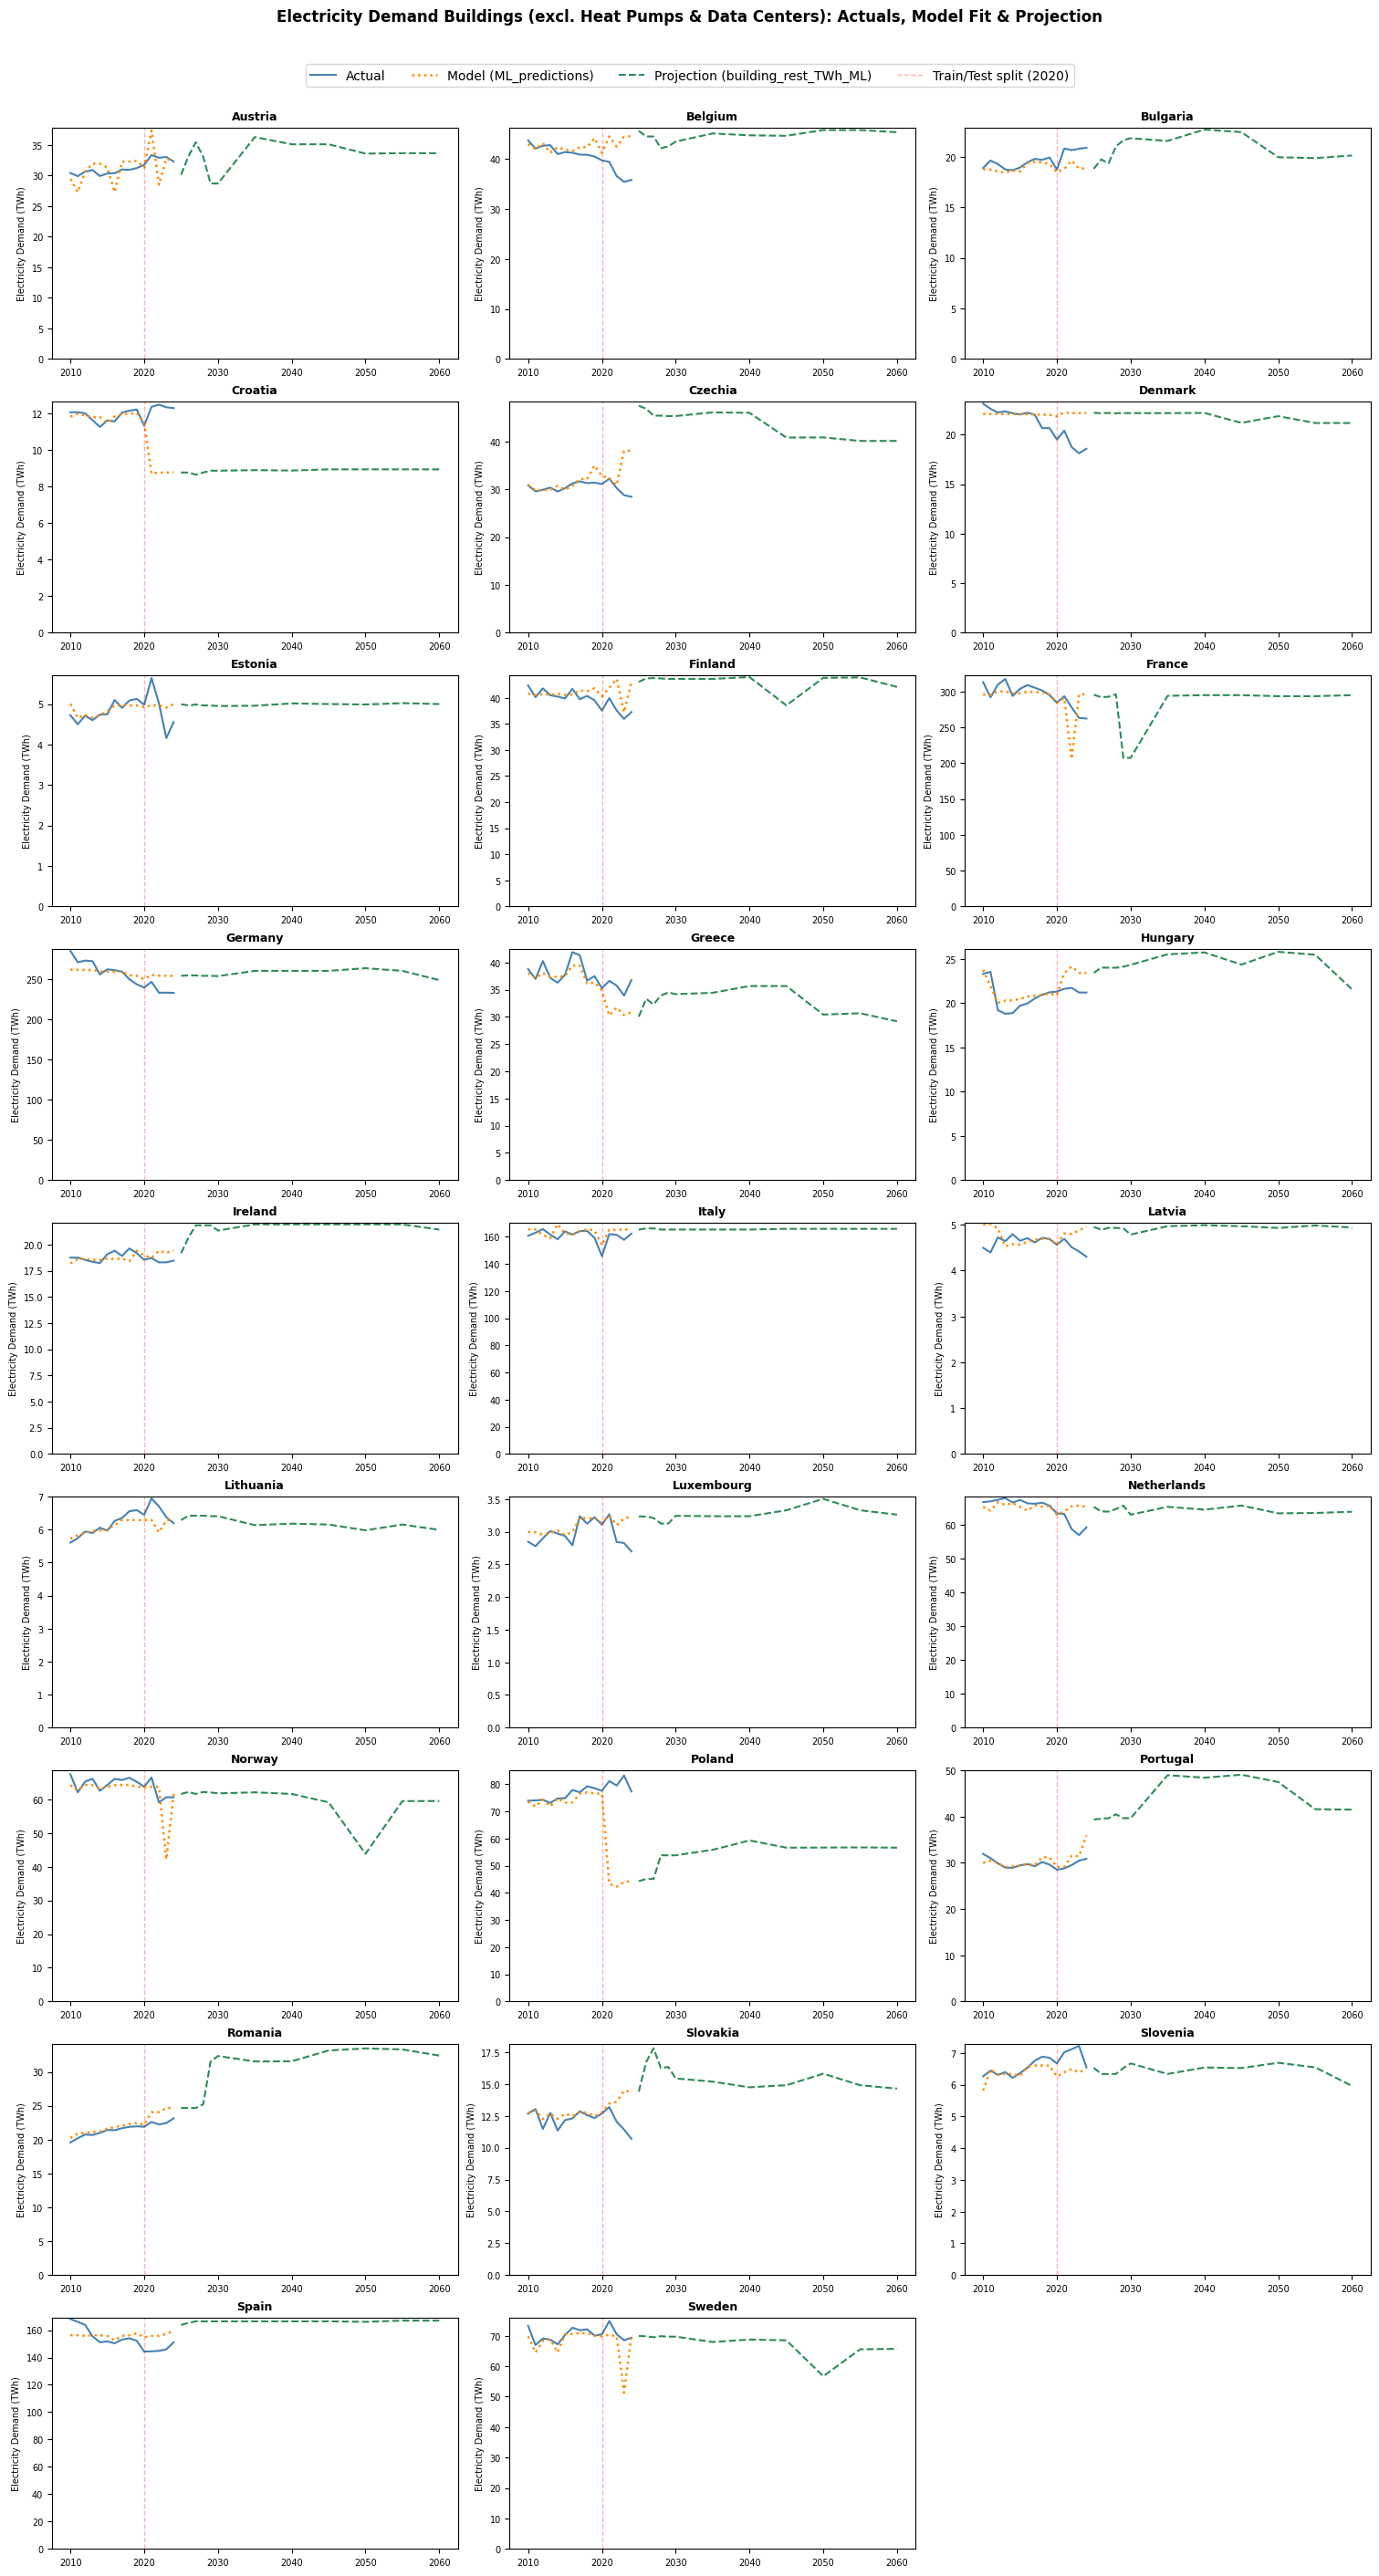

In [148]:
hist_ML = hist[["country", "year"] + FEATURES + TARGET]
proj_ML = proj[["country", "year"] + FEATURES]

X = hist_ML.drop(columns=TARGET)
X.country = X.country.astype('category')

y = hist_ML[TARGET]

categorical = ["country"]
numeric = FEATURES

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    #("cat", LabelEncoder(), categorical),
    ("num", "passthrough", numeric)
])

# XGBRegressor model with activation function: "log"
pipe = Pipeline([
    ("prep", preprocessor),
    ("rf", XGBRegressor(n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

YEAR_TEST_VAL = 2020
X_train = X[X.year <= YEAR_TEST_VAL]
X_test = X[X.year > YEAR_TEST_VAL]
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]



model.fit(X_train, y_train)

hist_ML["ML_predictions"] = model.predict(X)
proj_ML["building_rest_TWh_ML"] = model.predict(proj_ML)

# plotting the results of ML model
plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    #hist_actual_col="building_rest_TWh",
    #hist_pred_col="ML_predictions",      
    proj_pred_col="building_rest_TWh_ML",          
    #proj_pred_col=None,
    #train_test_split_year=YEAR_TEST_VAL
)

orig_train_pred = model.predict(X_train)
orig_test_pred  = model.predict(X_test)

print("=== Original model ===")
report_metrics("TRAIN",    y_train, orig_train_pred)
report_metrics("TEST",     y_test,  orig_test_pred)
print()

# Improved ML Model with Feature Engineering

In [149]:
# ── Feature Engineering ───────────────────────────────────────────────────────

# pull the log-transformed columns that already exist in panel
feat_eng = panel[["year", "country", "ln_pop", "ln_gdp_pc", "ln_hdd", "ln_cdd"]].copy()

hist_ML = hist_ML.merge(feat_eng, on=["year", "country"], how="left")
proj_ML = proj_ML.merge(feat_eng, on=["year", "country"], how="left")

# add interaction & combined features to both dataframes
for df in [hist_ML, proj_ML]:
    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]
    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population
    df["cdd_x_pop"]     = df["cdd_DegreesC"]   * df["population_Mio"]             # cooling load × population
    df["climate_total"] = df["hdd_DegreesC"]   + df["cdd_DegreesC"]               # total degree days

FEATURES_ENG = [
    # original features
    "population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent",
    "hdd_DegreesC", "cdd_DegreesC",
    # log transforms (linearise scale differences across countries)
    #"ln_pop", "ln_gdp_pc", "ln_hdd", "ln_cdd",
    # interaction & combined features
    "gdp_total", "hdd_x_pop", "cdd_x_pop", "climate_total",
]

print("New features added:", [#"ln_pop", "ln_gdp_pc", "ln_hdd", "ln_cdd",
                               "gdp_total", "hdd_x_pop", "cdd_x_pop", "climate_total"])
hist_ML[["country", "year"] + FEATURES_ENG].head(3)

New features added: ['gdp_total', 'hdd_x_pop', 'cdd_x_pop', 'climate_total']


,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,gdp_total,hdd_x_pop,cdd_x_pop,climate_total
0,Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,497.718354,32681.032707,222.087143,3939.718191
1,Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,609.766815,30505.677767,415.015186,2852.487448
2,Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,161.107921,16976.197160,1119.053880,2438.132789


=== Original model ===
TRAIN       MAPE=  2.57%  MAE=2  RMSE=3  R²=0.9981
TEST        MAPE= 12.27%  MAE=6  RMSE=13  R²=0.9673

=== Engineered model ===
TRAIN       MAPE=  2.07%  MAE=1  RMSE=3  R²=0.9988
TEST        MAPE=  9.67%  MAE=4  RMSE=7  R²=0.9902


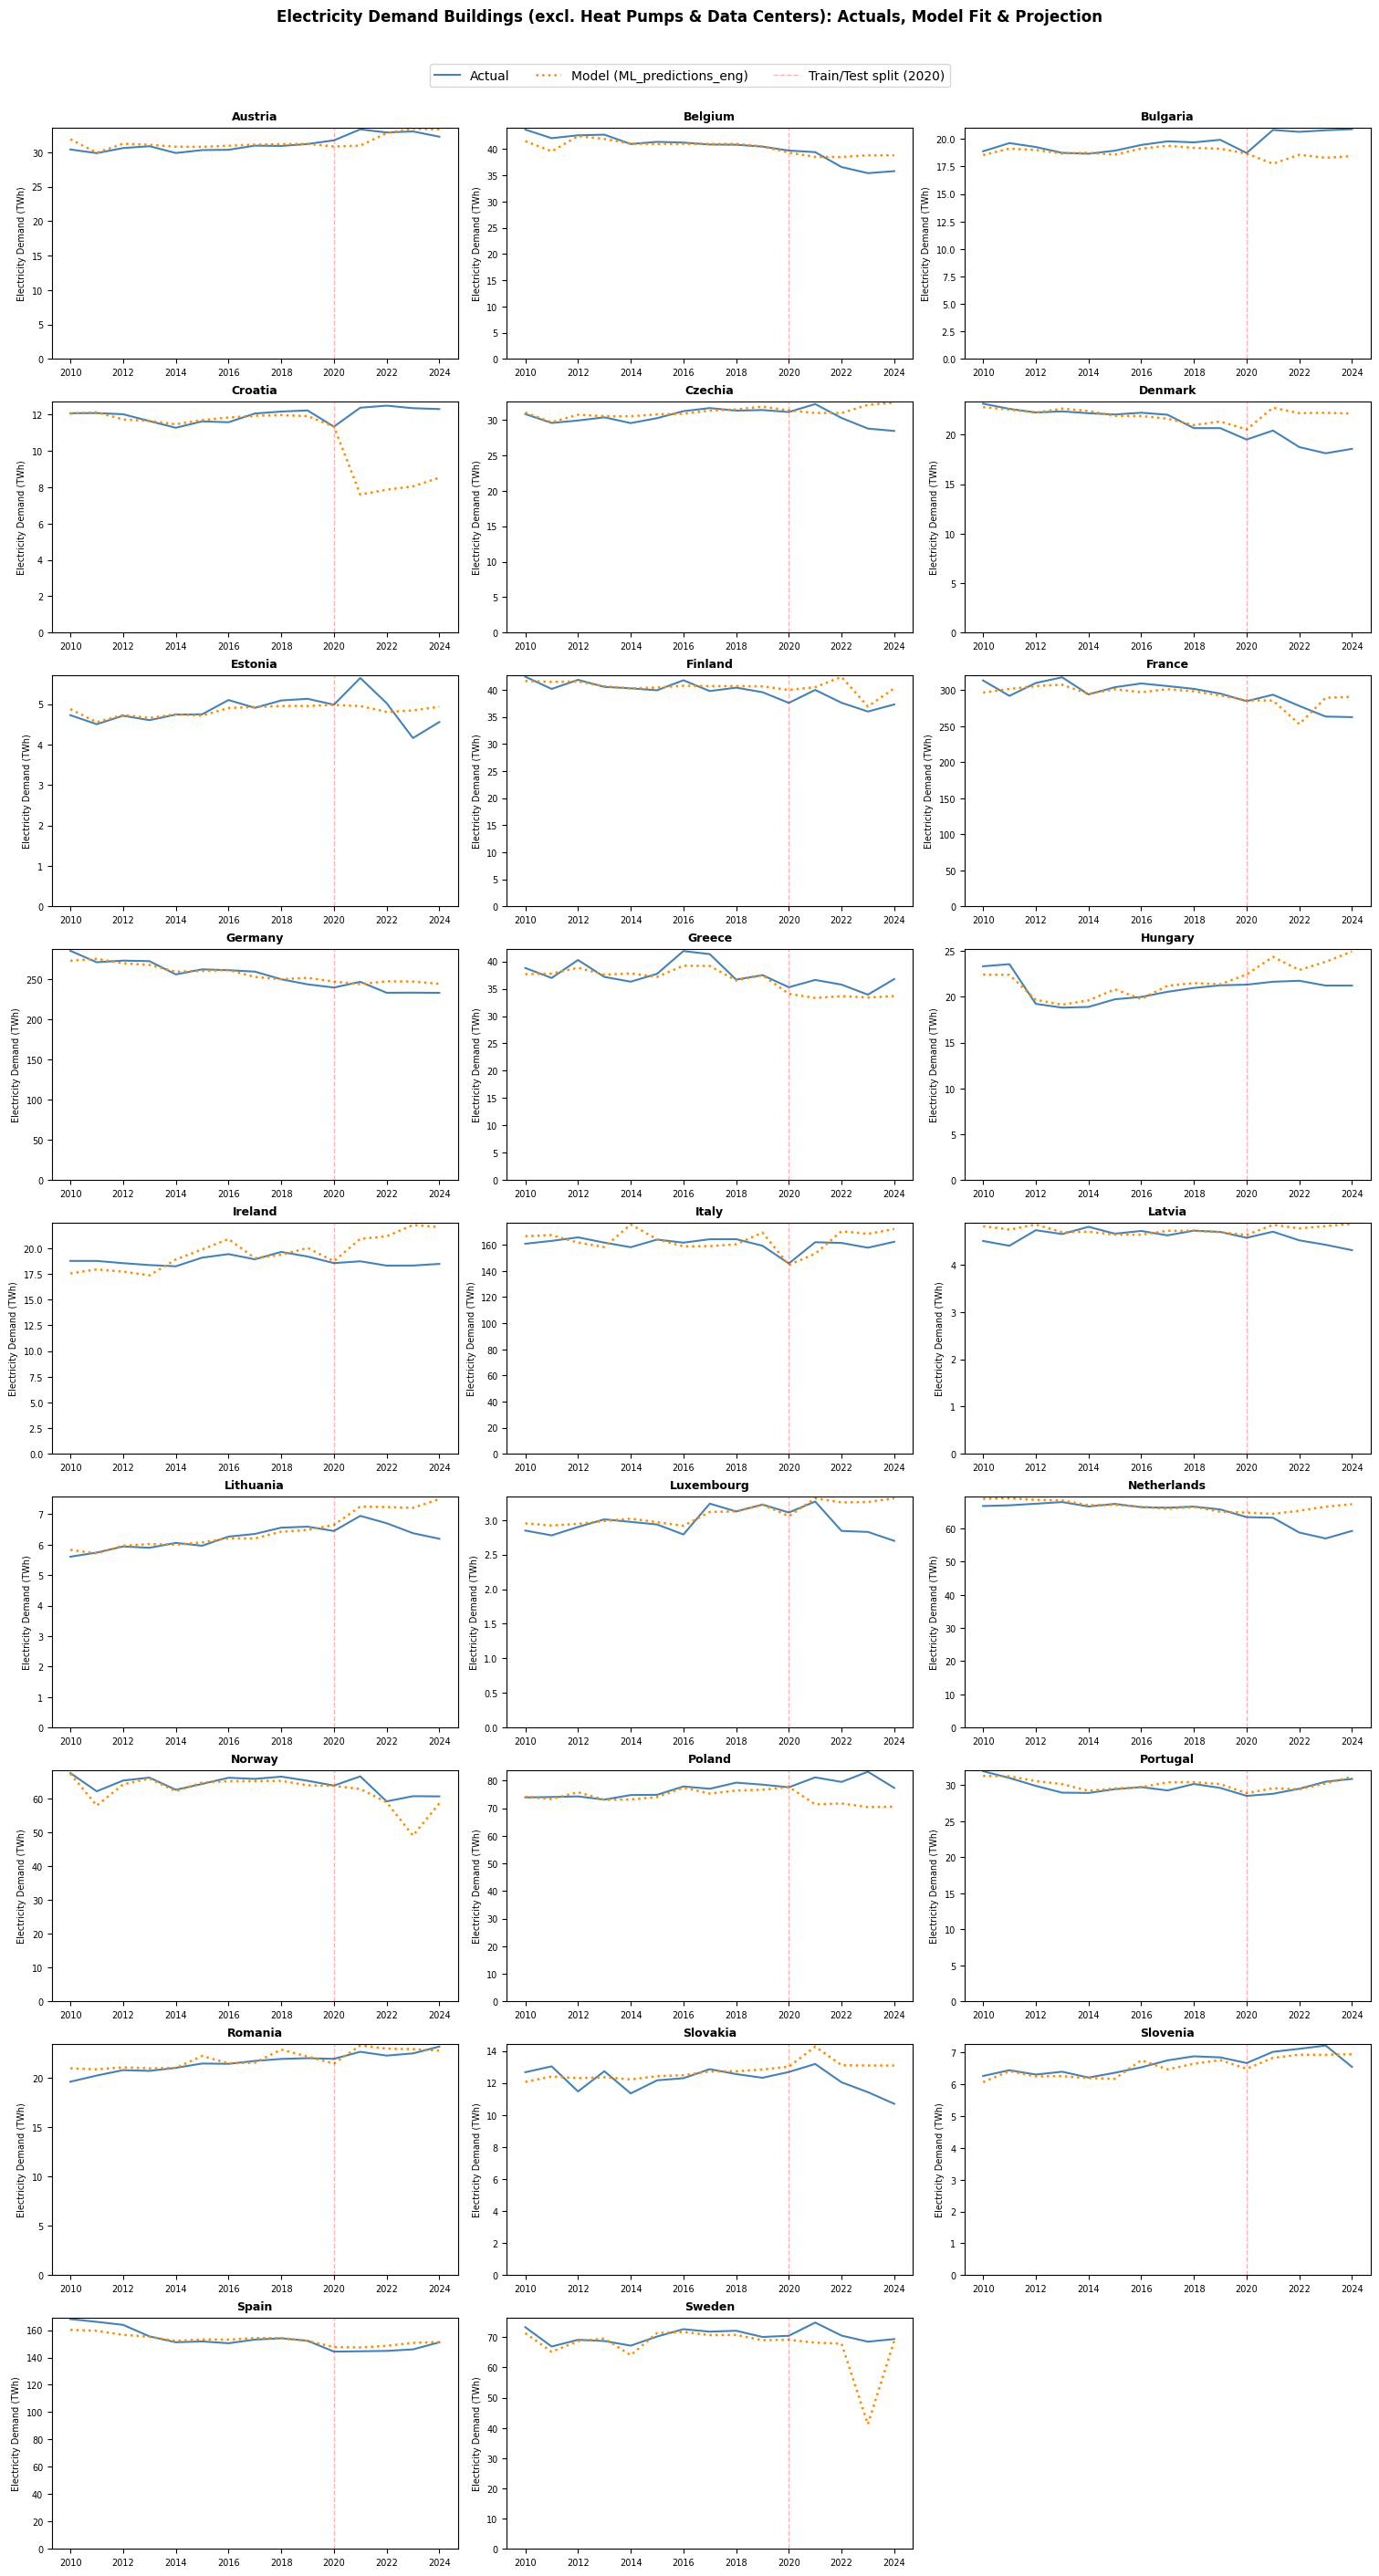

In [150]:
X_eng = hist_ML[["country", "year"] + FEATURES_ENG]
y_eng = hist_ML[TARGET]

preprocessor_eng = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["country"]),
    ("num", "passthrough", ["year"] + FEATURES_ENG)
])

pipe_eng = Pipeline([
    ("prep", preprocessor_eng),
    ("xgb", XGBRegressor(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 3,
        subsample        = 0.8,        # row subsampling → less overfitting
        colsample_bytree = 0.8,        # feature subsampling per tree
        min_child_weight = 3,          # min samples per leaf
        random_state     = 42,
    ))
])

model_eng = TransformedTargetRegressor(
    regressor=pipe_eng,
    func=np.log1p,
    inverse_func=np.expm1
)

X_train_eng = X_eng[X_eng.year <= YEAR_TEST_VAL]
X_test_eng  = X_eng[X_eng.year  > YEAR_TEST_VAL]
y_train_eng = y_eng.loc[X_train_eng.index]
y_test_eng  = y_eng.loc[X_test_eng.index]

model_eng.fit(X_train_eng, y_train_eng)

hist_ML["ML_predictions_eng"]          = model_eng.predict(X_eng)
proj_ML["buildings_rest_TWh_ML_eng"]   = model_eng.predict(proj_ML[["country", "year"] + FEATURES_ENG])

plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_pred_col="ML_predictions_eng",
    #proj_pred_col="buildings_rest_TWh_ML_eng",
    proj_pred_col=None,
    #train_test_split_year=YEAR_TEST_VAL
)

print("=== Original model ===")
report_metrics("TRAIN", y_train,     model.predict(X_train))
report_metrics("TEST",  y_test,      model.predict(X_test))

print("\n=== Engineered model ===")
report_metrics("TRAIN", y_train_eng, model_eng.predict(X_train_eng))
report_metrics("TEST",  y_test_eng,  model_eng.predict(X_test_eng))

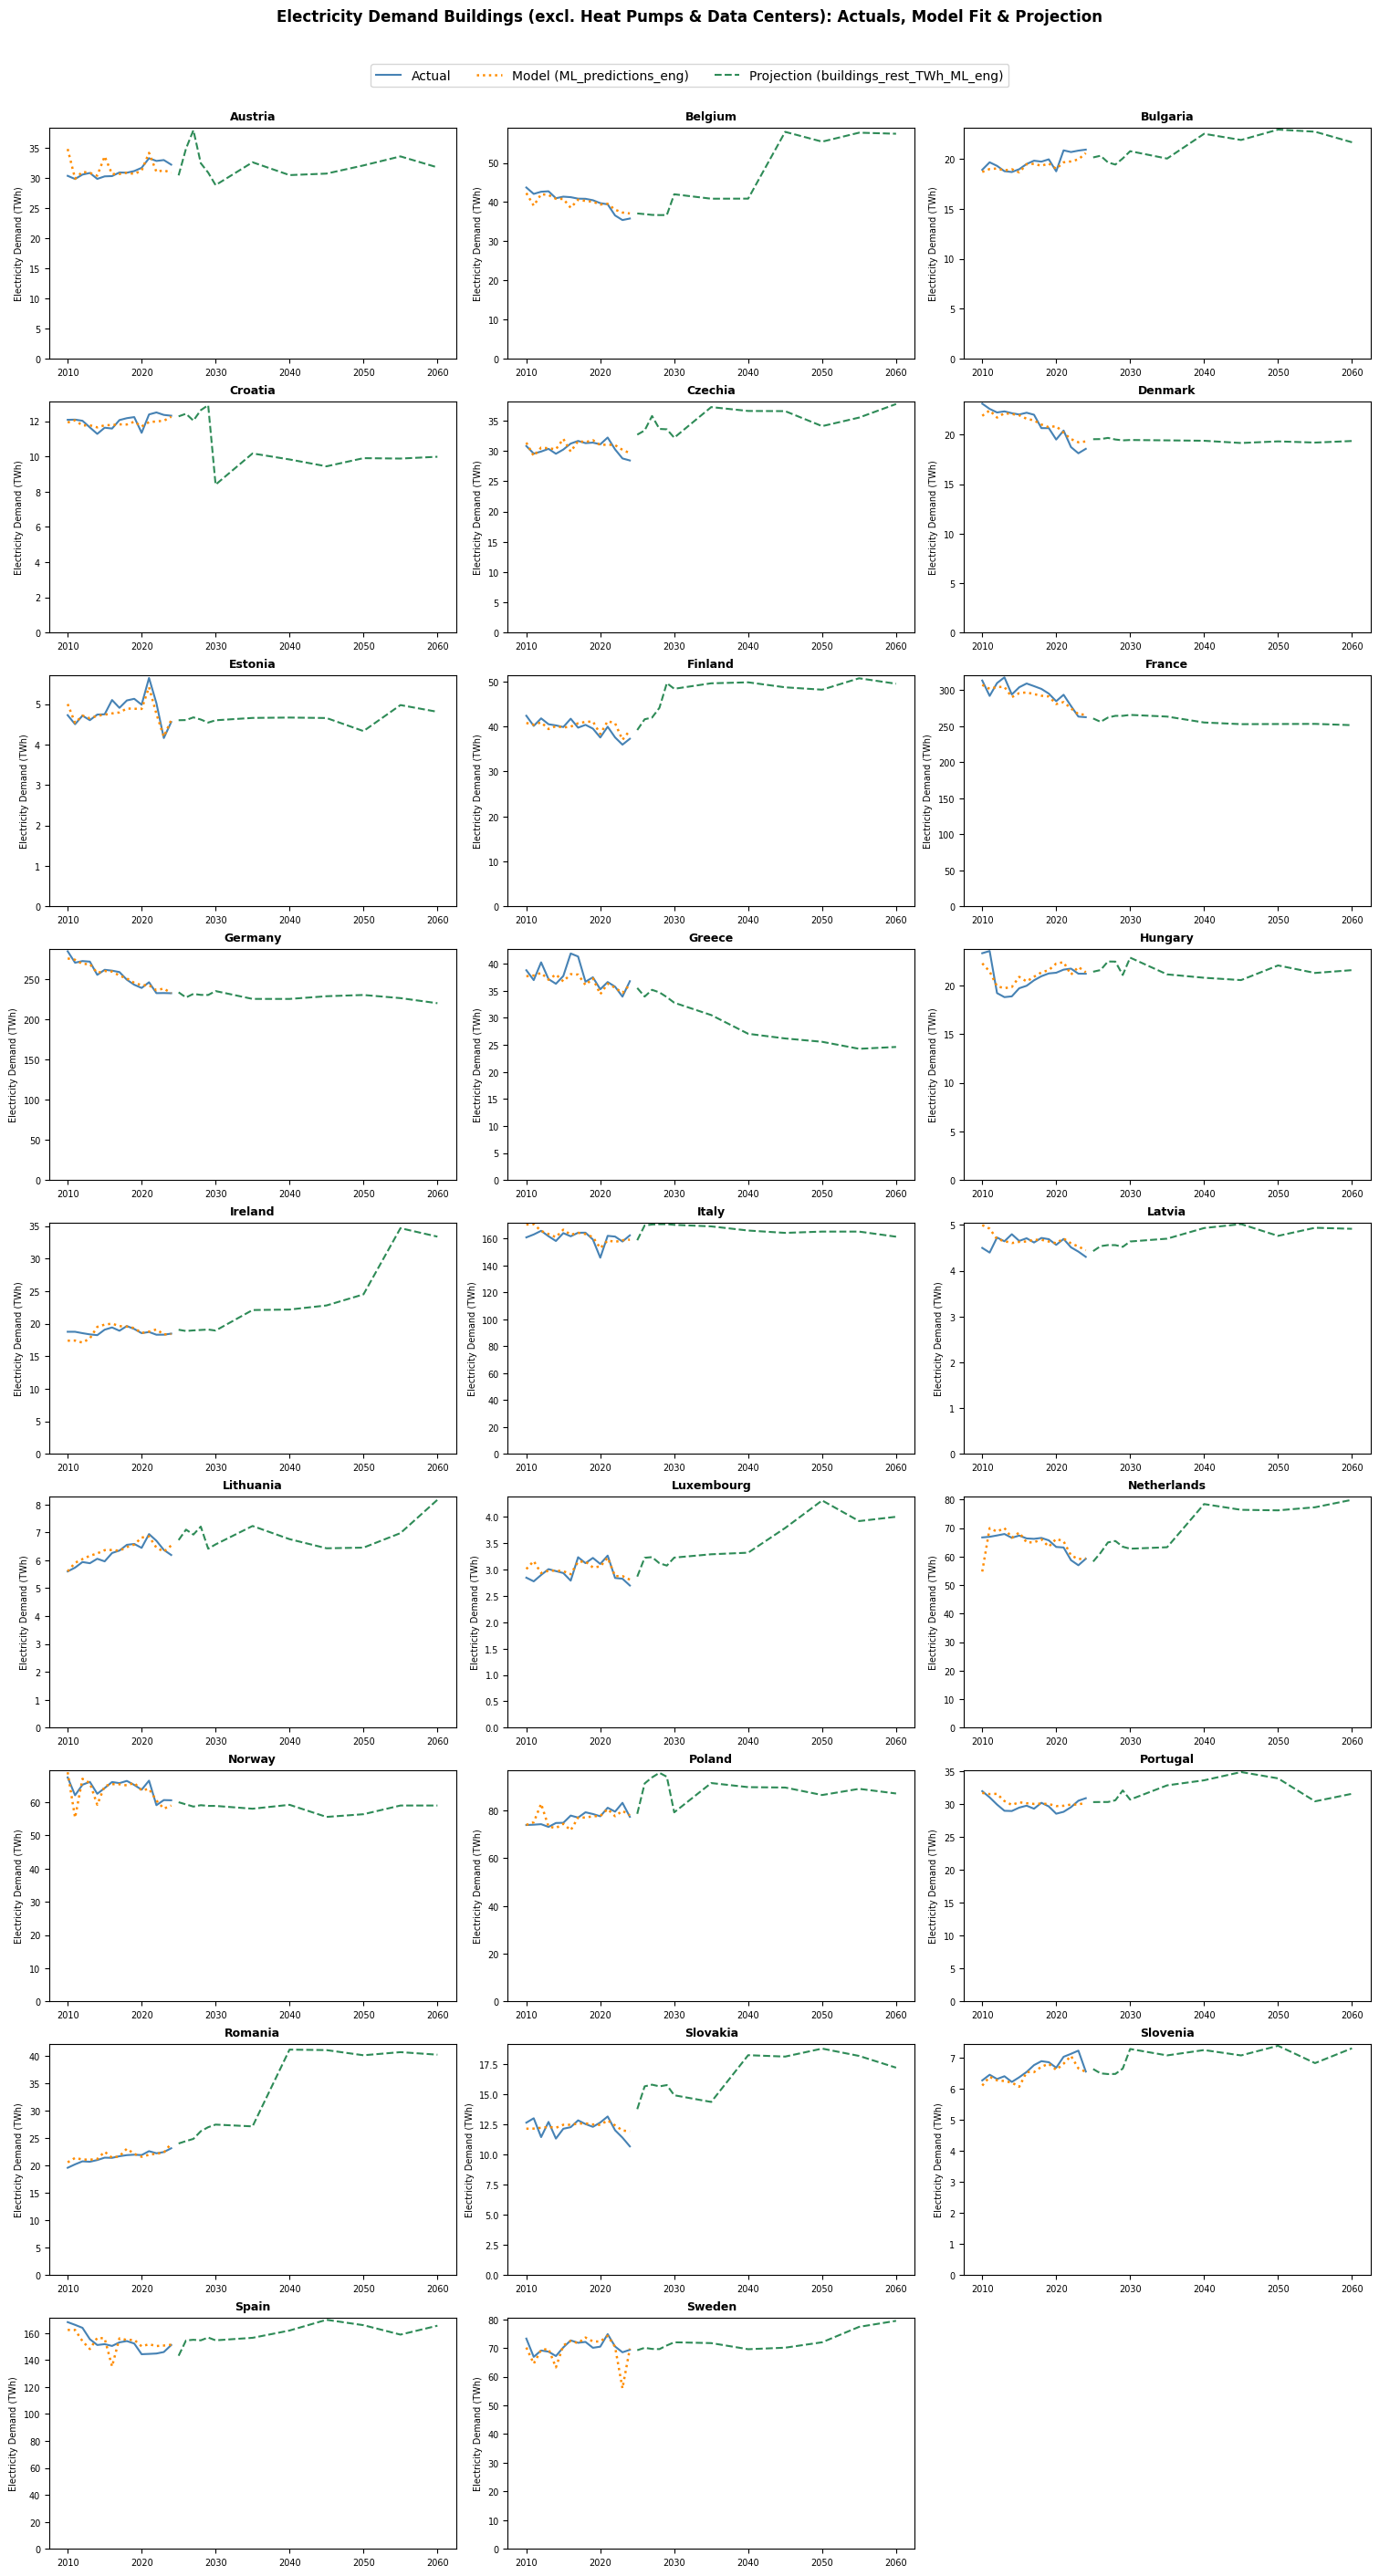

In [151]:
model_eng.fit(X_eng, y_eng)

hist_ML["ML_predictions_eng"]          = model_eng.predict(X_eng)
proj_ML["buildings_rest_TWh_ML_eng"]   = model_eng.predict(proj_ML[["country", "year"] + FEATURES_ENG])

plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_pred_col="ML_predictions_eng",
    proj_pred_col="buildings_rest_TWh_ML_eng",
    train_test_split_year=None
)